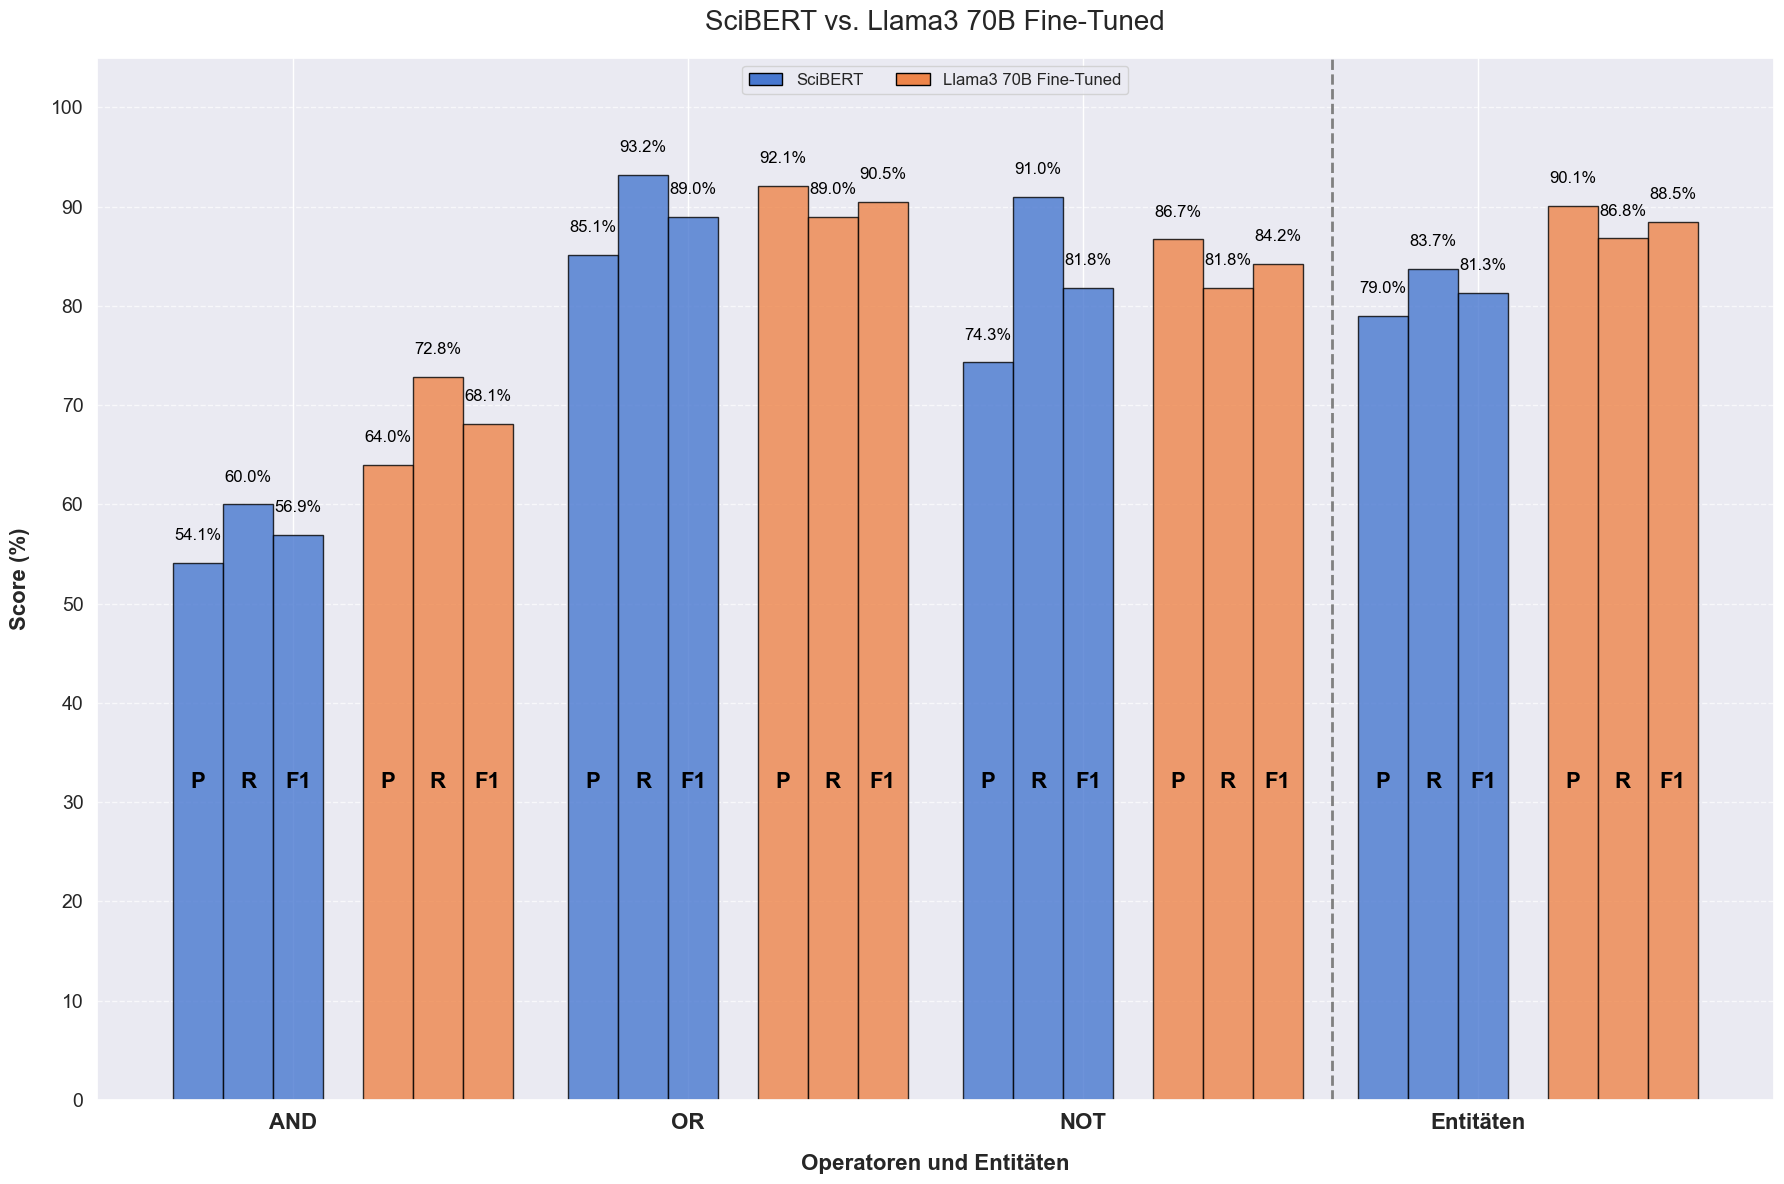

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
def plot_scientific_operator_and_entity_metrics(operator_metrics, entity_metrics):
    models = ['SciBERT', 'Llama3 70B Fine-Tuned']
    operators = ['AND', 'OR', 'NOT', 'Entitäten']
    metrics = ['P', 'R', 'F1']
    sns.set(style="darkgrid")
    fig, ax = plt.subplots(figsize=(18, 12))

    x = np.arange(len(operators))
    bar_width = 0.38
    opacity = 0.8
    gap = 0.1
    fixed_height = 32
    colors = sns.color_palette("muted", 2)

    for j, model in enumerate(models):
        for i, metric in enumerate(metrics):
            values = [
                operator_metrics[model]['AND'][metric],
                operator_metrics[model]['OR'][metric],
                operator_metrics[model]['NOT'][metric],
                entity_metrics[model][metric]
            ]

            offset = (j - 0.5) * (bar_width + gap) + i * bar_width / 3
            rects = ax.bar(x + offset, values, bar_width / 3, alpha=opacity,
                           color=colors[j], edgecolor='black', linewidth=1)

            for k, value in enumerate(values):
                if metric == 'R':
                    ax.text(x[k] + offset, fixed_height + 0, metric,
                            ha='center', va='center', fontsize=16, fontweight='bold', color='black')
                else:
                    ax.text(x[k] + offset, fixed_height, metric,
                            ha='center', va='center', fontsize=16, fontweight='bold', color='black')
                ax.text(x[k] + offset, value + 2, f'{value:.1f}%',
                        ha='center', va='bottom', fontsize=12, color='black')

    # Add separator line before "Entitäten"
    ax.axvline(x=2.63, color='gray', linestyle='--', linewidth=2)

    ax.set_xlabel('Operatoren und Entitäten', fontsize=16, fontweight='bold', labelpad=15)
    ax.set_ylabel('Score (%)', fontsize=16, fontweight='bold', labelpad=15)
    ax.set_title('SciBERT vs. Llama3 70B Fine-Tuned', fontsize=20, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(operators, fontsize=16, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.set_yticks(np.arange(0, 101, 10))
    ax.tick_params(axis='y', labelsize=14, width=2)
    ax.yaxis.set_tick_params(labelsize=14)

    legend_elements = [
        plt.Rectangle((0,0),1,1, facecolor=colors[0], edgecolor='black', label='SciBERT'),
        plt.Rectangle((0,0),1,1, facecolor=colors[1], edgecolor='black', label='Llama3 70B Fine-Tuned')
    ]
    ax.legend(handles=legend_elements, fontsize=12, ncol=2, loc='upper center')

    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig('pics/fine_tuned.png', bbox_inches='tight')
    plt.show()

# Data from the tables (unchanged)
operator_metrics = {
    'SciBERT': {
        'AND': {'P': 54.1, 'R': 60.0, 'F1': 56.9},
        'OR': {'P': 85.1, 'R': 93.2, 'F1': 89.0},
        'NOT': {'P': 74.3, 'R': 91.0, 'F1': 81.8}
    },
    'Llama3 70B Fine-Tuned': {
        'AND': {'P': 64.0, 'R': 72.8, 'F1': 68.1},
        'OR': {'P': 92.1, 'R': 89.0, 'F1': 90.5},
        'NOT': {'P': 86.7, 'R': 81.8, 'F1': 84.2}
    }
}

entity_metrics = {
    'SciBERT': {'P': 79.0, 'R': 83.7, 'F1': 81.3},
    'Llama3 70B Fine-Tuned': {'P': 90.1, 'R': 86.8, 'F1': 88.5}
}

plot_scientific_operator_and_entity_metrics(operator_metrics, entity_metrics)

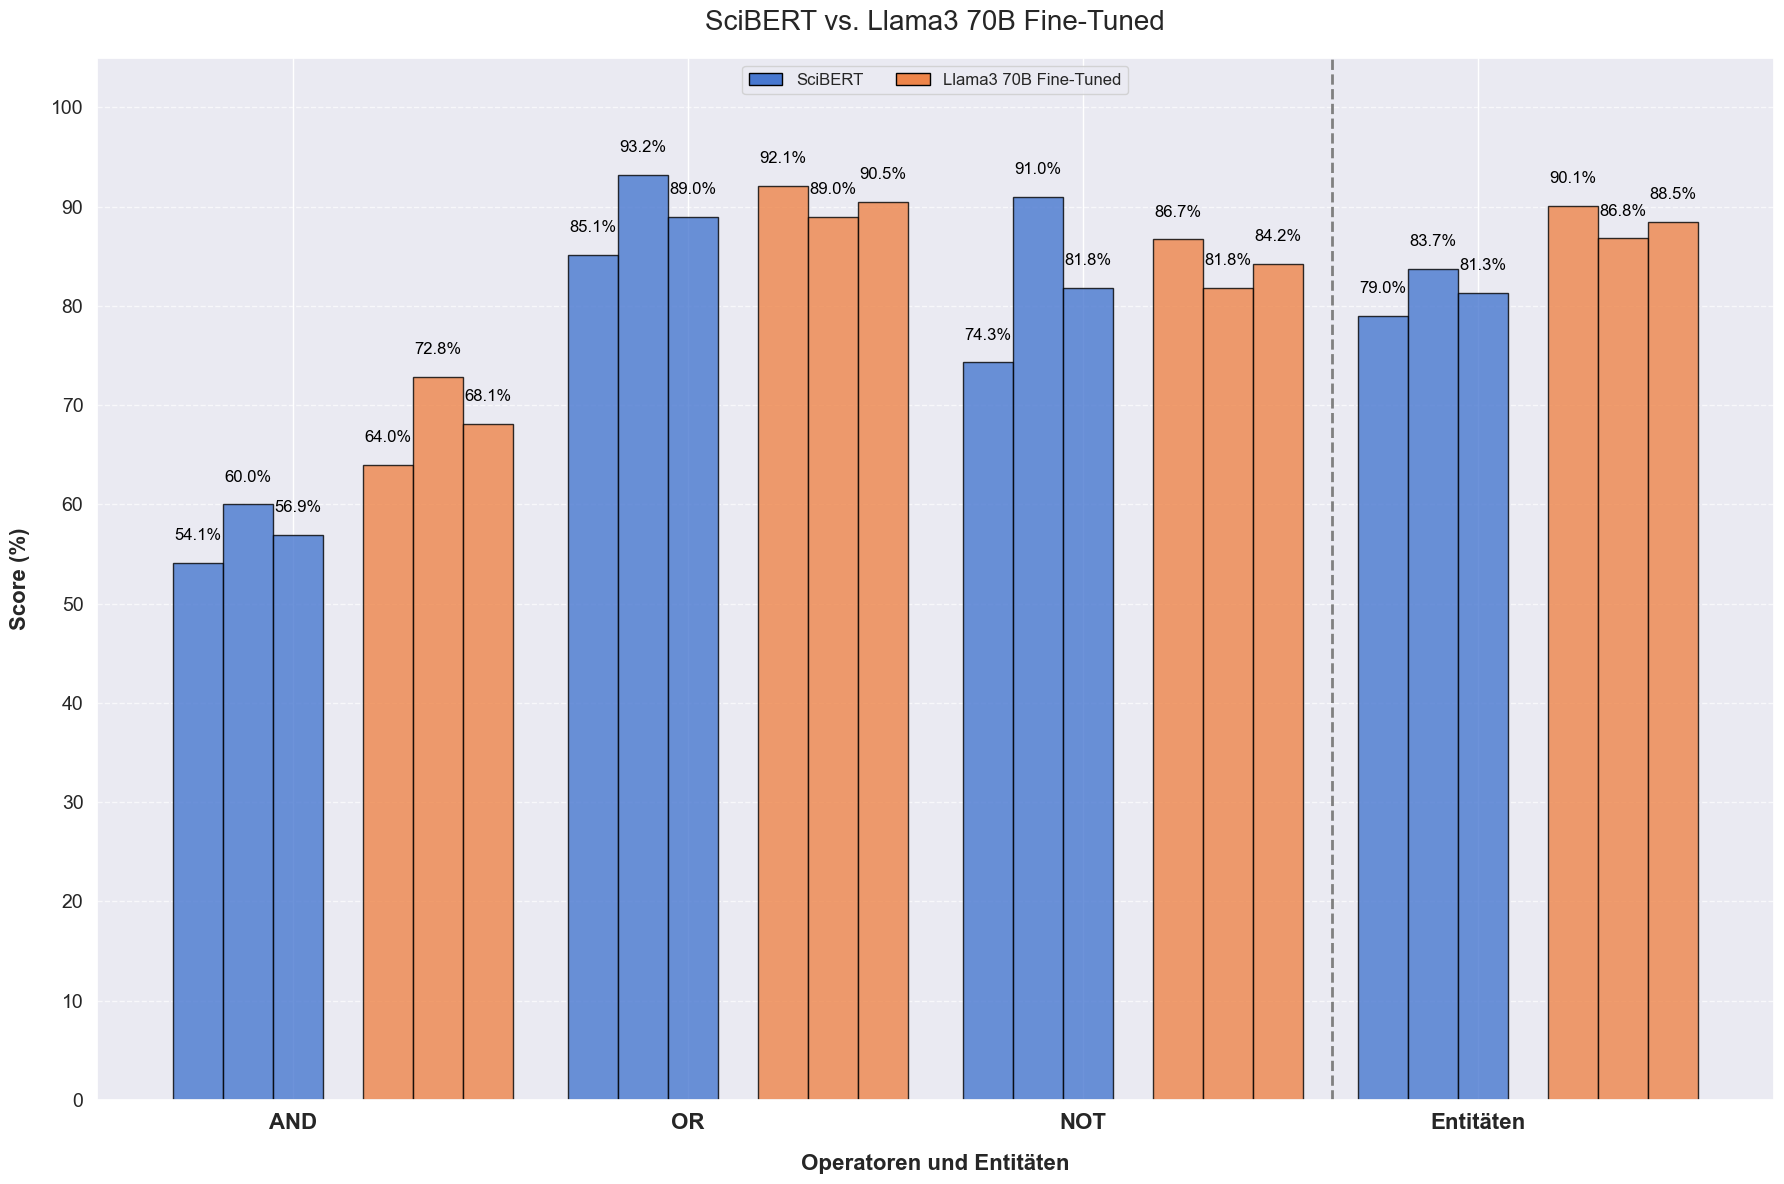

In [17]:
def plot_scientific_operator_and_entity_metrics(operator_metrics, entity_metrics):
    models = ['SciBERT', 'Llama3 70B Fine-Tuned']
    operators = ['AND', 'OR', 'NOT', 'Entitäten']
    metrics = ['P', 'R', 'F1']
    sns.set(style="darkgrid")
    fig, ax = plt.subplots(figsize=(18, 12))

    x = np.arange(len(operators))
    bar_width = 0.38
    opacity = 0.8
    gap = 0.1
    fixed_height = 32

    # Updated colors for better scientific clarity
    colors = sns.color_palette("muted", 2)

    for j, model in enumerate(models):
        for i, metric in enumerate(metrics):
            values = [
                operator_metrics[model]['AND'][metric],
                operator_metrics[model]['OR'][metric],
                operator_metrics[model]['NOT'][metric],
                entity_metrics[model][metric]
            ]

            offset = (j - 0.5) * (bar_width + gap) + i * bar_width / 3
            rects = ax.bar(x + offset, values, bar_width / 3, alpha=opacity,
                           color=colors[j], edgecolor='black', linewidth=1)

            for k, value in enumerate(values):
                ax.text(x[k] + offset, value + 2, f'{value:.1f}%',
                        ha='center', va='bottom', fontsize=12, color='black')

    # Add separator line before "Entitäten"
    ax.axvline(x=2.63, color='gray', linestyle='--', linewidth=2)

    ax.set_xlabel('Operatoren und Entitäten', fontsize=16, fontweight='bold', labelpad=15)
    ax.set_ylabel('Score (%)', fontsize=16, fontweight='bold', labelpad=15)
    ax.set_title('SciBERT vs. Llama3 70B Fine-Tuned', fontsize=20, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(operators, fontsize=16, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.set_yticks(np.arange(0, 101, 10))
    ax.tick_params(axis='y', labelsize=14, width=2)
    ax.yaxis.set_tick_params(labelsize=14)

    # Creating a clearer legend with distinct colors
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[0], edgecolor='black', label='SciBERT'),
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[1], edgecolor='black', label='Llama3 70B Fine-Tuned')
    ]
    ax.legend(handles=legend_elements, fontsize=12, ncol=2, loc='upper center')

    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig('fine_tuned_scientific.png', bbox_inches='tight')
    plt.show()

# Data from the tables (unchanged)
operator_metrics = {
    'SciBERT': {
        'AND': {'P': 54.1, 'R': 60.0, 'F1': 56.9},
        'OR': {'P': 85.1, 'R': 93.2, 'F1': 89.0},
        'NOT': {'P': 74.3, 'R': 91.0, 'F1': 81.8}
    },
    'Llama3 70B Fine-Tuned': {
        'AND': {'P': 64.0, 'R': 72.8, 'F1': 68.1},
        'OR': {'P': 92.1, 'R': 89.0, 'F1': 90.5},
        'NOT': {'P': 86.7, 'R': 81.8, 'F1': 84.2}
    }
}

entity_metrics = {
    'SciBERT': {'P': 79.0, 'R': 83.7, 'F1': 81.3},
    'Llama3 70B Fine-Tuned': {'P': 90.1, 'R': 86.8, 'F1': 88.5}
}

plot_scientific_operator_and_entity_metrics(operator_metrics, entity_metrics)